In [4]:
import os
import kagglehub
from PIL import Image

# 1. Redirect Kaggle dataset cache and Temp paths to D: Drive[cite: 1]
os.environ["KAGGLEHUB_CACHE"] = r"D:\kaggle_cache"
os.environ["TEMP"] = r"D:\pip_temp"
os.environ["TMP"] = r"D:\pip_temp"

# 2. Create dedicated project output directories on D: Drive[cite: 1]
PROJECT_DIR = r"D:\NeuroScan"
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
METRICS_DIR = os.path.join(PROJECT_DIR, "metrics")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

# 3. Download dataset directly into D: Drive cache[cite: 1]
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Dataset downloaded on D: Drive at:", path)

# 4. Verify image integrity and remove corrupt files[cite: 1, 2]
def clean_and_verify_dataset(base_path):
    valid_count = 0
    corrupt_count = 0
    non_image_count = 0

    print(f"\nScanning dataset directory: {base_path}\n" + "=" * 50)

    for root, _, files in os.walk(base_path):
        for file in files:
            file_path = os.path.join(root, file)

            if not file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                non_image_count += 1
                continue

            try:
                with Image.open(file_path) as img:
                    img.verify()
                valid_count += 1
            except Exception as e:
                print(f"Corrupt image detected: {file_path} | Error: {e}")
                corrupt_count += 1
                try:
                    os.remove(file_path)
                except Exception:
                    pass

    print("=" * 50)
    print(f"Verification Finished!\n✔ Valid Images: {valid_count}\n✖ Corrupt Images: {corrupt_count}")

clean_and_verify_dataset(path)

c:\Users\dell\anaconda3\envs\tf_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded on D: Drive at: D:\kaggle_cache\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2

Scanning dataset directory: D:\kaggle_cache\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2
Verification Finished!
✔ Valid Images: 7200
✖ Corrupt Images: 0


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = os.path.join(path, 'Training')
test_dir = os.path.join(path, 'Testing')

# Data Augmentation on Training data[cite: 2]
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.15
)

# Test generator (only preprocessing, no augmentation)[cite: 2]
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print("\nClass labels detected:", class_names)

Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Class labels detected: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [6]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Base Model (EfficientNetB0)[cite: 1, 2]
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze top 25 layers for optimal feature adaptation on MRI scans
base_model.trainable = True
for layer in base_model.layers[:-25]:
    layer.trainable = False

# Keep BatchNormalization frozen for training stability
for layer in base_model.layers[-25:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Custom Classification Head[cite: 1, 2]
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Save best weights directly into D:\NeuroScan\models\
model_save_path = os.path.join(MODEL_DIR, "brain_tumor_model.keras")

callbacks = [
    ModelCheckpoint(model_save_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)
]

print("Starting training...")
history = model.fit(
    train_generator,
    epochs=12,
    validation_data=val_generator,
    callbacks=callbacks
)

Starting training...
Epoch 1/12
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6371 - loss: 1.0142
Epoch 1: val_accuracy improved from None to 0.84405, saving model to D:\NeuroScan\models\brain_tumor_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 401s 2s/step - accuracy: 0.7422 - loss: 0.7213 - val_accuracy: 0.8440 - val_loss: 0.4939 - learning_rate: 1.0000e-04
Epoch 2/12
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8339 - loss: 0.4437
Epoch 2: val_accuracy improved from 0.84405 to 0.87738, saving model to D:\NeuroScan\models\brain_tumor_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 404s 3s/step - accuracy: 0.8521 - loss: 0.4119 - val_accuracy: 0.8774 - val_loss: 0.3179 - learning_rate: 1.0000e-04
Epoch 3/12
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8840 - loss: 0.3112
Epoch 3: val_accuracy improved from 0.87738 to 0.90476, saving model to D:\NeuroScan\models\brain_tumor_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.8805 - loss: 0.3186 - val_accur

50/50 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9175 - loss: 0.3490

Final Test Accuracy: 91.75%
50/50 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step


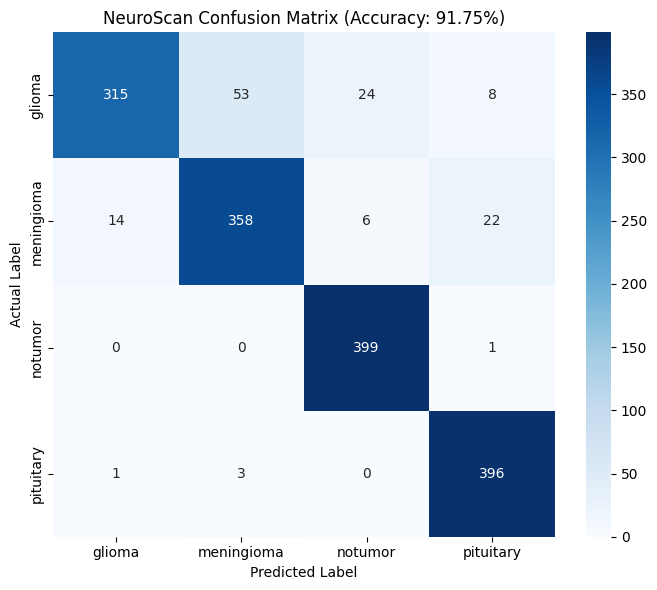


✔ Confusion Matrix saved at: D:\NeuroScan\metrics\confusion_matrix.png
✔ Best model saved at: D:\NeuroScan\models\brain_tumor_model.keras

--- Classification Report ---
              precision    recall  f1-score   support

      glioma       0.95      0.79      0.86       400
  meningioma       0.86      0.90      0.88       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.93      0.99      0.96       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Evaluate on Unseen Test Generator[cite: 2]
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

# 2. Generate Predictions[cite: 1]
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Plot and Save Confusion Matrix to D: Drive[cite: 1]
cm_save_path = os.path.join(METRICS_DIR, "confusion_matrix.png")

plt.figure(figsize=(7, 6))
sns.heatmap(
    confusion_matrix(y_true, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title(f"NeuroScan Confusion Matrix (Accuracy: {test_acc * 100:.2f}%)", fontsize=12)
plt.xlabel("Predicted Label", fontsize=10)
plt.ylabel("Actual Label", fontsize=10)
plt.tight_layout()
plt.savefig(cm_save_path, dpi=300)
plt.show()

print(f"\n✔ Confusion Matrix saved at: {cm_save_path}")
print(f"✔ Best model saved at: {model_save_path}")

# 4. Detailed Classification Report[cite: 1]
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

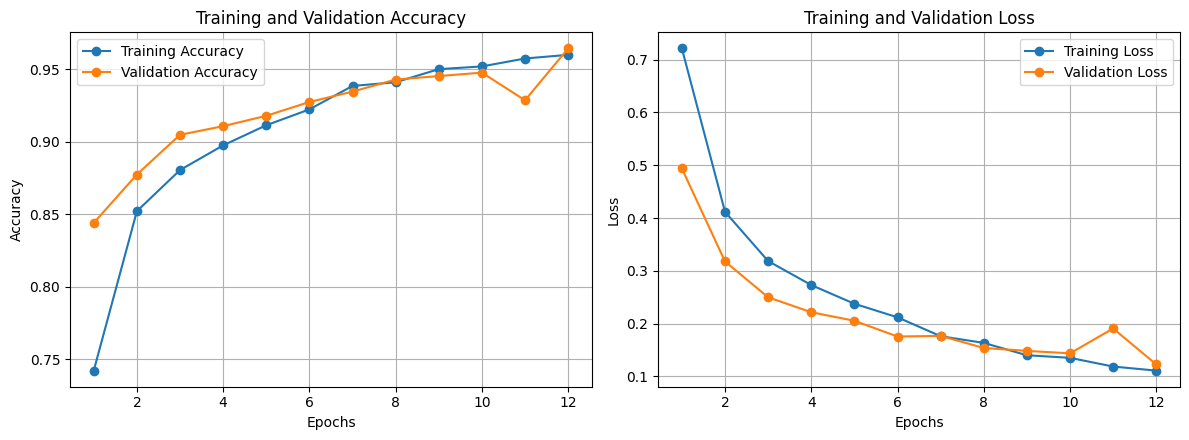

In [8]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4.5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()